# Match Coinbase products to existing assets

Pulls every product from the Coinbase Advanced Trade public API plus per-currency metadata from the Exchange `/currencies` endpoint, then tries to match the `base_currency_id` / `quote_currency_id` codes against rows in the local `asset` table. Output is a set of review tables you can scan in bulk to confirm or override matches before inserting `provider_asset` rows for the Coinbase provider.

**Inputs:** `POSTGRES_URL` from `.env`. No Coinbase auth needed — both endpoints are public.

**Outputs:**
1. `review.csv` — one row per unique Coinbase currency code with the best local-asset match, the match strategy used, the Coinbase name + description (so you can validate each match), and example products that reference that code.
2. `local_assets_no_coinbase.csv` — active local assets whose symbol does not appear in any Coinbase product. These won't get a `provider_asset` row from this run.
3. `price_check.csv` — for each matched asset with a `{base}-USD` Coinbase pair, the Coinbase price vs latest Kraken close (in USD) and the percent difference. Use this to spot bad matches: a >5% gap usually means the ticker collided with an unrelated asset.
4. `provider_asset` rows in Postgres — the final cell upserts directly via SQLAlchemy. No `.sql` file is generated; review the CSVs first, then run the cell.

In [34]:
import os
import datetime as dt
from collections import Counter, defaultdict

import pandas as pd
import requests
from dotenv import load_dotenv
from sqlalchemy import create_engine, select

import mc_postgres_db.models as models

load_dotenv()

POSTGRES_URL = os.getenv("POSTGRES_URL")
engine = create_engine(POSTGRES_URL)

PRODUCTS_URL = "https://api.coinbase.com/api/v3/brokerage/market/products"
CURRENCIES_URL = "https://api.exchange.coinbase.com/currencies"

## Load local assets and existing Coinbase mappings

Pulls the canonical `asset` table plus any `provider_asset` rows that already point at the Coinbase provider, so we can flag codes that are already mapped.

In [35]:
asset_df = pd.read_sql(
    select(
        models.Asset.id,
        models.Asset.symbol,
        models.Asset.name,
        models.Asset.description,
        models.Asset.is_active,
    ),
    engine,
)

provider_df = pd.read_sql(
    select(models.Provider.id, models.Provider.name),
    engine,
)

coinbase_provider = provider_df[provider_df["name"] == "Coinbase"]
coinbase_provider_id = (
    int(coinbase_provider["id"].iloc[0]) if not coinbase_provider.empty else None
)

# All active provider_asset rows so we can show how each local asset is coded
# on other providers (e.g., "Kraken:XBT, OKX:BTC-USD") during review.
all_provider_assets = pd.read_sql(
    select(
        models.ProviderAsset.provider_id,
        models.ProviderAsset.asset_id,
        models.ProviderAsset.asset_code,
        models.ProviderAsset.date,
        models.ProviderAsset.is_active,
    ).where(models.ProviderAsset.is_active == True),
    engine,
)
latest_provider_assets = (
    all_provider_assets.sort_values("date")
    .drop_duplicates(["asset_id", "provider_id"], keep="last")
    .merge(
        provider_df.rename(columns={"id": "provider_id", "name": "provider_name"}),
        on="provider_id",
        how="left",
    )
)

provider_codes_by_asset: dict[int, str] = {}
for aid, group in latest_provider_assets.groupby("asset_id"):
    rows = group.sort_values("provider_name")
    provider_codes_by_asset[int(aid)] = ", ".join(
        f"{r['provider_name']}:{r['asset_code']}" for _, r in rows.iterrows()
    )

asset_description_by_id: dict[int, str] = {
    int(r["id"]): r["description"]
    for _, r in asset_df.iterrows()
    if pd.notna(r["description"])
}

existing_mappings = (
    all_provider_assets[all_provider_assets["provider_id"] == coinbase_provider_id][
        ["asset_code", "asset_id", "date", "is_active"]
    ].copy()
    if coinbase_provider_id is not None
    else pd.DataFrame(columns=["asset_code", "asset_id", "date", "is_active"])
)

print(f"Local assets: {len(asset_df):,} ({asset_df['is_active'].sum()} active)")
print(f"Coinbase provider id: {coinbase_provider_id}")
print(f"Existing Coinbase provider_asset rows: {len(existing_mappings):,}")
print(
    f"All providers: {latest_provider_assets['provider_name'].nunique()} distinct, "
    f"{len(latest_provider_assets):,} active (asset, provider) rows"
)

Local assets: 86 (83 active)
Coinbase provider id: 56
Existing Coinbase provider_asset rows: 0
All providers: 2 distinct, 87 active (asset, provider) rows


## Fetch Coinbase products

In [36]:
resp = requests.get(PRODUCTS_URL, timeout=30)
resp.raise_for_status()
products = resp.json().get("products", [])

products_df = pd.DataFrame(products)
print(f"Coinbase returned {len(products_df):,} products")
products_df.head()

Coinbase returned 919 products


,product_id,price,price_percentage_change_24h,volume_24h,volume_percentage_change_24h,base_increment,quote_increment,quote_min_size,quote_max_size,base_min_size,...,base_cbrn,quote_cbrn,product_cbrn,icon_color,icon_url,display_name_overwrite,is_alpha_testing,about_description,best_bid_price,best_ask_price
0,BTC-USD,78325.03,2.66075068343264,7718.05508989,-8.9116983889607,0.00000001,0.01,1,150000000,0.00000001,...,,,,,,,False,,,
1,BTC-USDC,78327.48,2.66396190261984,7716.9953885,-8.92420495942512,0.00000001,0.01,1,150000000,0.00000001,...,,,,,,,False,,,
2,ETH-USD,2307.3,2.00355440808495,124157.37470114,-31.56675323460206,0.00000001,0.01,1,150000000,0.00000001,...,,,,,,,False,,,
3,ETH-USDC,2307.3,2.00355440808495,124156.91760683,-31.56700517652486,0.00000001,0.01,1,150000000,0.00000001,...,,,,,,,False,,,
4,SOL-USD,84.21,1.20177863237592,830223.96808262,-36.66894007686626,0.00000001,0.01,1,25000000,0.00000001,...,,,,,,,False,,,


## Filter to live spot products
Same filter logic as the loader: status=="online" and not disabled in any way.

In [37]:
def _bool(series: pd.Series) -> pd.Series:
    return series.fillna(False).astype(bool)

live_mask = (
    (products_df["status"] == "online")
    & ~_bool(products_df.get("is_disabled", False))
    & ~_bool(products_df.get("trading_disabled", False))
    & ~_bool(products_df.get("view_only", False))
    & ~_bool(products_df.get("auction_mode", False))
)
live_df = products_df.loc[live_mask].copy()
print(f"Live products: {len(live_df):,} / {len(products_df):,}")

Live products: 913 / 919


## Fetch Coinbase per-currency metadata

`/market/products` only gives us currency codes. The legacy Exchange `/currencies` endpoint returns the full name plus a description for each currency, which lets us sanity-check that a `BTC → BTC` match really means the same Bitcoin we have locally (and not, say, a wrapped or testnet variant that happens to share a ticker).

In [38]:
cresp = requests.get(CURRENCIES_URL, timeout=30)
cresp.raise_for_status()
currencies = cresp.json()

currency_records = []
for c in currencies:
    details = c.get("details") or {}
    currency_records.append(
        {
            "coinbase_code": c.get("id"),
            "coinbase_name": c.get("name"),
            "coinbase_status": c.get("status"),
            "coinbase_type": details.get("type"),
            "coinbase_display_name": details.get("display_name"),
            "coinbase_description": details.get("description"),
        }
    )

currencies_df = pd.DataFrame(currency_records).drop_duplicates(subset="coinbase_code")
print(f"Coinbase returned metadata for {len(currencies_df):,} currencies")
currencies_df.head()

Coinbase returned metadata for 485 currencies


,coinbase_code,coinbase_name,coinbase_status,coinbase_type,coinbase_display_name,coinbase_description
0,00,00 Token,online,crypto,None,None
1,1INCH,1Inch,online,crypto,None,None
2,2Z,Doublezero,online,crypto,None,None
3,A8,Ancient8,online,crypto,None,None
4,AAVE,Aave,online,crypto,None,None


## Collect unique currency codes used by Coinbase

We care about the codes that appear in `base_currency_id` / `quote_currency_id` — those are the strings that need to land in `provider_asset.asset_code`. We also keep counts (how many products use each side) and a few example product ids per code so the review table has context.

In [39]:
base_counts: Counter[str] = Counter()
quote_counts: Counter[str] = Counter()
examples: dict[str, list[str]] = defaultdict(list)

for _, row in live_df.iterrows():
    base = row["base_currency_id"]
    quote = row["quote_currency_id"]
    pid = row["product_id"]
    if isinstance(base, str):
        base_counts[base] += 1
        if len(examples[base]) < 3:
            examples[base].append(pid)
    if isinstance(quote, str):
        quote_counts[quote] += 1
        if len(examples[quote]) < 3:
            examples[quote].append(pid)

codes_df = pd.DataFrame(
    [
        {
            "coinbase_code": code,
            "base_count": base_counts.get(code, 0),
            "quote_count": quote_counts.get(code, 0),
            "total_products": base_counts.get(code, 0) + quote_counts.get(code, 0),
            "example_products": ", ".join(examples[code]),
        }
        for code in sorted(set(base_counts) | set(quote_counts))
    ]
).sort_values("total_products", ascending=False)

codes_df = codes_df.merge(currencies_df, on="coinbase_code", how="left")

missing_meta = codes_df["coinbase_name"].isna().sum()
print(f"{len(codes_df):,} unique Coinbase currency codes ({missing_meta} without /currencies metadata)")
codes_df.head(15)

405 unique Coinbase currency codes (0 without /currencies metadata)


,coinbase_code,base_count,quote_count,total_products,example_products,coinbase_name,coinbase_status,coinbase_type,coinbase_display_name,coinbase_description
0,USDC,6,397,403,"BTC-USDC, ETH-USDC, SOL-USDC",USDC,online,crypto,None,None
1,USD,0,393,393,"BTC-USD, ETH-USD, SOL-USD",United States Dollar,online,fiat,US Dollar,None
2,EUR,0,35,35,"USDC-EUR, BTC-EUR, ETH-EUR",Euro,online,fiat,None,None
3,USDT,4,28,32,"USDT-USD, BTC-USDT, USDT-USDC",Tether,online,crypto,None,None
4,BTC,5,24,29,"BTC-USD, BTC-USDC, BTC-EUR",Bitcoin,online,crypto,None,None
5,GBP,0,26,26,"BTC-GBP, USDC-GBP, ETH-GBP",British Pound,online,fiat,None,None
6,ETH,6,6,12,"ETH-USD, ETH-USDC, ETH-EUR",Ether,online,crypto,None,None
7,LINK,7,0,7,"LINK-USD, LINK-USDC, LINK-EUR",Chainlink,online,crypto,None,None
8,ADA,7,0,7,"ADA-USD, ADA-USDC, ADA-EUR",Cardano,online,crypto,None,None
9,SOL,7,0,7,"SOL-USD, SOL-USDC, SOL-EUR",Solana,online,crypto,None,None


## Match codes to local assets

Strategy, in order:
1. **`exact_symbol`** — `Asset.symbol == coinbase_code` (case-sensitive)
2. **`exact_name`** — `Asset.name == coinbase_code` (case-sensitive)
3. **`ci_symbol`** — case-insensitive symbol match
4. **`ci_name`** — case-insensitive name match
5. **`already_mapped`** — there's already a `provider_asset` row for this code on Coinbase
6. **`unmatched`** — needs manual review

If multiple local assets match a code (rare but possible if `symbol` is null and `name` collides) we record all candidate ids.

In [40]:
active = asset_df[asset_df["is_active"].fillna(True).astype(bool)].copy()

by_symbol = active.dropna(subset=["symbol"]).groupby("symbol")["id"].apply(list).to_dict()
by_name = active.dropna(subset=["name"]).groupby("name")["id"].apply(list).to_dict()
by_symbol_ci = (
    active.dropna(subset=["symbol"])
    .assign(_k=lambda d: d["symbol"].str.lower())
    .groupby("_k")["id"]
    .apply(list)
    .to_dict()
)
by_name_ci = (
    active.dropna(subset=["name"])
    .assign(_k=lambda d: d["name"].str.lower())
    .groupby("_k")["id"]
    .apply(list)
    .to_dict()
)

already_mapped_codes = set(
    existing_mappings.loc[existing_mappings["is_active"].fillna(True), "asset_code"]
)

asset_label = active.set_index("id").apply(
    lambda r: f"{r['symbol'] or r['name']} ({r['name']})", axis=1
).to_dict()


def match_code(code: str) -> dict[str, object]:
    if code in already_mapped_codes:
        ids = existing_mappings.loc[
            existing_mappings["asset_code"] == code, "asset_id"
        ].tolist()
        return {
            "match_type": "already_mapped",
            "asset_ids": ids,
            "asset_labels": [asset_label.get(i, str(i)) for i in ids],
        }
    for label, lookup, key in (
        ("exact_symbol", by_symbol, code),
        ("exact_name", by_name, code),
        ("ci_symbol", by_symbol_ci, code.lower()),
        ("ci_name", by_name_ci, code.lower()),
    ):
        if key in lookup:
            ids = lookup[key]
            return {
                "match_type": label,
                "asset_ids": ids,
                "asset_labels": [asset_label.get(i, str(i)) for i in ids],
            }
    return {"match_type": "unmatched", "asset_ids": [], "asset_labels": []}


match_records = codes_df["coinbase_code"].apply(match_code).tolist()
matches = pd.concat([codes_df.reset_index(drop=True), pd.DataFrame(match_records)], axis=1)
matches["asset_id"] = matches["asset_ids"].apply(
    lambda xs: xs[0] if len(xs) == 1 else None
)
matches["ambiguous"] = matches["asset_ids"].apply(lambda xs: len(xs) > 1)
matches["asset_labels_str"] = matches["asset_labels"].apply(", ".join)

matches["match_type"].value_counts(dropna=False)

match_type
unmatched       331
exact_symbol     74
Name: count, dtype: int64

## Fuzzy match the remaining unmatched codes

Anything that didn't hit `exact_symbol` / `exact_name` / `ci_symbol` / `ci_name` falls through to a fuzzy pass. We score the Coinbase `coinbase_name` (when available) and the raw `coinbase_code` against every active local asset's `symbol` and `name` using `difflib.SequenceMatcher.ratio()`, take the best score per code, and promote anything above `FUZZY_THRESHOLD` to `match_type = "fuzzy"`.

Fuzzy matches are intentionally **excluded from the auto-upsert at the bottom** — eyeball them in `review.csv` (the `fuzzy_score` column shows the confidence), and only promote them by adding `"fuzzy"` to the insertable filter once you trust the score.

In [41]:
import difflib

FUZZY_THRESHOLD = 0.85

fuzzy_targets: list[tuple[int, str, str]] = []
for _, a in active.iterrows():
    aid = int(a["id"])
    label = f"{a['symbol'] or a['name']} ({a['name']})"
    if isinstance(a["symbol"], str) and a["symbol"]:
        fuzzy_targets.append((aid, label, a["symbol"].lower()))
    if isinstance(a["name"], str) and a["name"]:
        fuzzy_targets.append((aid, label, a["name"].lower()))


def fuzzy_best(query: str) -> tuple[int | None, str, float]:
    q = (query or "").lower().strip()
    if not q:
        return (None, "", 0.0)
    best = (None, "", 0.0)
    for aid, label, target in fuzzy_targets:
        score = difflib.SequenceMatcher(None, q, target).ratio()
        if score > best[2]:
            best = (aid, label, score)
    return best


matches["fuzzy_score"] = float("nan")
matches["fuzzy_query"] = ""

unmatched_idx = matches.index[matches["match_type"] == "unmatched"]
for idx in unmatched_idx:
    code = matches.at[idx, "coinbase_code"]
    name_val = matches.at[idx, "coinbase_name"]
    name = name_val if isinstance(name_val, str) else None

    candidates: list[tuple[int | None, str, float, str]] = []
    if name:
        aid, label, score = fuzzy_best(name)
        candidates.append((aid, label, score, name))
    aid, label, score = fuzzy_best(code)
    candidates.append((aid, label, score, code))

    aid, label, score, query = max(candidates, key=lambda x: x[2])
    matches.at[idx, "fuzzy_score"] = score
    matches.at[idx, "fuzzy_query"] = query
    if score >= FUZZY_THRESHOLD and aid is not None:
        matches.at[idx, "match_type"] = "fuzzy"
        matches.at[idx, "asset_id"] = aid
        matches.at[idx, "asset_ids"] = [aid]
        matches.at[idx, "asset_labels"] = [label]
        matches.at[idx, "asset_labels_str"] = label

print(
    f"Fuzzy promoted {(matches['match_type'] == 'fuzzy').sum()} of "
    f"{len(unmatched_idx)} previously unmatched codes (threshold={FUZZY_THRESHOLD})"
)
matches["match_type"].value_counts(dropna=False)

Fuzzy promoted 7 of 331 previously unmatched codes (threshold=0.85)


match_type
unmatched       324
exact_symbol     74
fuzzy             7
Name: count, dtype: int64

## Review table

Sorted by match type then by total product volume. Skim the `unmatched` block first — those need a new `Asset` row or a manual override.

In [42]:
matches["asset_description"] = matches["asset_id"].map(
    lambda x: asset_description_by_id.get(int(x)) if pd.notna(x) else None
)
matches["asset_provider_codes"] = matches["asset_id"].map(
    lambda x: provider_codes_by_asset.get(int(x), "") if pd.notna(x) else ""
)

match_order = pd.Categorical(
    matches["match_type"],
    categories=[
        "unmatched",
        "fuzzy",
        "ambiguous",
        "ci_name",
        "ci_symbol",
        "exact_name",
        "exact_symbol",
        "already_mapped",
    ],
    ordered=True,
)
matches_sorted = matches.assign(_order=match_order).sort_values(
    ["_order", "fuzzy_score", "total_products"],
    ascending=[True, False, False],
    na_position="last",
).drop(columns="_order")

review_cols = [
    "coinbase_code",
    "coinbase_name",
    "coinbase_type",
    "coinbase_description",
    "match_type",
    "fuzzy_score",
    "fuzzy_query",
    "asset_id",
    "asset_labels_str",
    "asset_description",
    "asset_provider_codes",
    "ambiguous",
    "base_count",
    "quote_count",
    "total_products",
    "example_products",
]
review_df = matches_sorted[review_cols].rename(
    columns={"asset_labels_str": "asset_labels"}
)
review_df.to_csv("review.csv", index=False)
print(f"Wrote {len(review_df):,} rows to review.csv")
review_df

Wrote 405 rows to review.csv


,coinbase_code,coinbase_name,coinbase_type,coinbase_description,match_type,fuzzy_score,fuzzy_query,asset_id,asset_labels,asset_description,asset_provider_codes,ambiguous,base_count,quote_count,total_products,example_products
127,FLOCK,Flock,crypto,None,unmatched,0.8,Flock,NaN,,None,,False,2,0,2,"FLOCK-USDC, FLOCK-USD"
239,OPG,Opengradient,crypto,None,unmatched,0.8,OPG,NaN,,None,,False,2,0,2,"OPG-USD, OPG-USDC"
240,OPN,OPINION,crypto,None,unmatched,0.8,OPN,NaN,,None,,False,2,0,2,"OPN-USDC, OPN-USD"
295,SD,Stader,crypto,None,unmatched,0.8,SD,NaN,,None,,False,2,0,2,"SD-USDC, SD-USD"
350,UP,Superform,crypto,None,unmatched,0.8,UP,NaN,,None,,False,2,0,2,"UP-USD, UP-USDC"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,TON,Toncoin,crypto,None,exact_symbol,NaN,,24.0,TON (TON),Toncoin,Kraken:TON,False,2,0,2,"TON-USD, TON-USDC"
344,TRUMP,Official Trump,crypto,None,exact_symbol,NaN,,51.0,TRUMP (TRUMP),OFFICIAL TRUMP,Kraken:TRUMP,False,2,0,2,"TRUMP-USDC, TRUMP-USD"
360,VIRTUAL,Virtuals Protocol,crypto,None,exact_symbol,NaN,,82.0,VIRTUAL (VIRTUAL),Virtuals Protocol,Kraken:VIRTUAL,False,2,0,2,"VIRTUAL-USDC, VIRTUAL-USD"
365,WLD,Worldcoin,crypto,None,exact_symbol,NaN,,47.0,WLD (WLD),Worldcoin,Kraken:WLD,False,2,0,2,"WLD-USD, WLD-USDC"


## Local assets with no Coinbase product

Inverse view: which active assets in our local `asset` table don't appear in any Coinbase product? These won't get a `provider_asset` row from this run, either because Coinbase doesn't list them or because Coinbase trades them under a different code. Investigate each one before assuming Coinbase coverage is complete.

In [43]:
coinbase_codes_set = set(codes_df["coinbase_code"])
coinbase_codes_lower = {c.lower() for c in coinbase_codes_set}

matched_asset_ids = set(
    int(x) for x in matches["asset_ids"].explode().dropna().tolist()
)

local_missing = active[~active["id"].isin(matched_asset_ids)].copy()
local_missing["symbol_lower"] = local_missing["symbol"].str.lower()
local_missing["coinbase_has_symbol_ci"] = local_missing["symbol_lower"].isin(
    coinbase_codes_lower
)

local_missing = local_missing[["id", "symbol", "name", "coinbase_has_symbol_ci"]].sort_values(
    ["coinbase_has_symbol_ci", "symbol"], ascending=[False, True]
)

local_missing.to_csv("local_assets_no_coinbase.csv", index=False)
print(
    f"{len(local_missing):,} active local assets are not matched to a Coinbase product "
    f"({local_missing['coinbase_has_symbol_ci'].sum()} have a symbol that DOES exist on Coinbase "
    "but matched a different local asset — check those for ticker collisions)"
)
local_missing

9 active local assets are not matched to a Coinbase product (0 have a symbol that DOES exist on Coinbase but matched a different local asset — check those for ticker collisions)


,id,symbol,name,coinbase_has_symbol_ci
75,83,A,A,False
73,81,GALA,GALA,False
48,55,JUP,JUP,False
35,42,KAS,KAS,False
26,33,MNT,MNT,False
84,66,PYUSD,PYUSD,False
85,87,RLUSD,RLUSD,False
9,11,TRX,TRX,False
23,30,XMR,XMR,False


## Sanity check: Coinbase price vs latest Kraken close

For each matched asset with a `{base}-USD` product on Coinbase, compare Coinbase's current product price against the latest Kraken close (also in USD) for the same local asset id. Big divergences (~5%+) usually mean we mapped a Coinbase ticker to the wrong local asset — e.g., a symbol collision between two similarly-named tokens.

In [44]:
kraken_provider = provider_df[provider_df["name"] == "Kraken"]
kraken_provider_id = (
    int(kraken_provider["id"].iloc[0]) if not kraken_provider.empty else None
)

usd_asset = active[active["symbol"] == "USD"]
usd_asset_id = int(usd_asset["id"].iloc[0]) if not usd_asset.empty else None

matched_for_price = matches[
    matches["match_type"].isin(
        ["exact_symbol", "exact_name", "ci_symbol", "ci_name", "already_mapped"]
    )
    & matches["asset_id"].notna()
    & ~matches["ambiguous"]
][["coinbase_code", "asset_id", "coinbase_name", "asset_labels_str"]]
matched_asset_ids = matched_for_price["asset_id"].astype(int).tolist()

KRAKEN_LOOKBACK_DAYS = 7
cutoff = dt.datetime.now(dt.timezone.utc) - dt.timedelta(days=KRAKEN_LOOKBACK_DAYS)

if kraken_provider_id is None or usd_asset_id is None or not matched_asset_ids:
    print(
        "Skipping price check: "
        f"kraken_provider_id={kraken_provider_id}, usd_asset_id={usd_asset_id}, "
        f"matched_asset_ids={len(matched_asset_ids)}"
    )
    price_check = pd.DataFrame()
else:
    m = models.ProviderAssetMarket
    latest_stmt = (
        select(m.to_asset_id, m.timestamp, m.close)
        .where(m.timestamp >= cutoff)
        .where(m.provider_id == kraken_provider_id)
        .where(m.from_asset_id == usd_asset_id)
        .where(m.to_asset_id.in_(matched_asset_ids))
        .order_by(m.to_asset_id, m.timestamp.desc())
        .distinct(m.to_asset_id)
    )
    latest_kraken = pd.read_sql(latest_stmt, engine).rename(
        columns={
            "to_asset_id": "asset_id",
            "close": "kraken_close",
            "timestamp": "kraken_timestamp",
        }
    )

    cb_usd = live_df[live_df["quote_currency_id"] == "USD"][
        ["base_currency_id", "price", "product_id"]
    ].copy()
    cb_usd["price"] = pd.to_numeric(cb_usd["price"], errors="coerce")
    cb_usd = cb_usd.rename(
        columns={
            "base_currency_id": "coinbase_code",
            "price": "coinbase_price",
            "product_id": "coinbase_product_id",
        }
    )

    price_check = (
        matched_for_price.merge(cb_usd, on="coinbase_code", how="inner")
        .merge(latest_kraken, on="asset_id", how="left")
    )
    price_check["pct_diff"] = (
        (price_check["coinbase_price"] - price_check["kraken_close"])
        / price_check["kraken_close"]
        * 100
    )
    price_check["abs_pct_diff"] = price_check["pct_diff"].abs()
    price_check = price_check.sort_values(
        "abs_pct_diff", ascending=False, na_position="first"
    )

    cols = [
        "coinbase_code",
        "coinbase_name",
        "asset_id",
        "asset_labels_str",
        "coinbase_product_id",
        "coinbase_price",
        "kraken_close",
        "kraken_timestamp",
        "pct_diff",
    ]
    price_check = price_check[cols].rename(columns={"asset_labels_str": "asset_labels"})
    price_check.to_csv("price_check.csv", index=False)

    n_no_kraken = price_check["kraken_close"].isna().sum()
    n_big = (price_check["pct_diff"].abs() > 5).sum()
    print(
        f"{len(price_check)} matched assets have a Coinbase USD pair; "
        f"{n_no_kraken} have no Kraken close in the last {KRAKEN_LOOKBACK_DAYS}d; "
        f"{n_big} differ from Kraken by >5%"
    )

price_check

72 matched assets have a Coinbase USD pair; 0 have no Kraken close in the last 7d; 0 differ from Kraken by >5%


,coinbase_code,coinbase_name,asset_id,asset_labels,coinbase_product_id,coinbase_price,kraken_close,kraken_timestamp,pct_diff
51,PENDLE,Pendle,73.0,PENDLE (PENDLE),PENDLE-USD,1.51800,1.55400,2026-05-01 14:33:00,-2.316602
65,TAO,Bittensor,35.0,TAO (TAO),TAO-USD,266.89000,262.00000,2026-05-01 14:33:00,1.866412
7,DOT,Polkadot,27.0,DOT (DOT),DOT-USD,1.21300,1.22770,2026-05-01 14:32:00,-1.197361
62,SPX,Spx6900,62.0,SPX (SPX),SPX-USD,0.37490,0.37140,2026-05-01 14:33:00,0.942380
31,OP,Optimism,59.0,OP (OP),OP-USD,0.12300,0.12210,2026-05-01 14:33:00,0.737101
...,...,...,...,...,...,...,...,...,...
48,MORPHO,Morpho,80.0,MORPHO (MORPHO),MORPHO-USD,1.97450,1.97422,2026-05-01 14:32:00,0.014183
0,USDT,Tether,18.0,USDT (USDT),USDT-USD,0.99979,0.99980,2026-05-01 14:34:00,-0.001000
26,JASMY,JasmyCoin,84.0,JASMY (JASMY),JASMY-USD,0.00566,0.00566,2026-05-01 14:32:00,0.000000
27,IMX,ImmutableX,67.0,IMX (IMX),IMX-USD,0.17030,0.17030,2026-05-01 14:32:00,0.000000


## Per-bucket breakdown

In [45]:
for bucket in [
    "unmatched",
    "fuzzy",
    "ci_symbol",
    "ci_name",
    "exact_symbol",
    "exact_name",
    "already_mapped",
]:
    sub = review_df[review_df["match_type"] == bucket]
    if sub.empty:
        continue
    print(f"\n=== {bucket} ({len(sub)}) ===")
    print(sub.to_string(index=False))


=== unmatched (324) ===
coinbase_code               coinbase_name coinbase_type coinbase_description match_type  fuzzy_score         fuzzy_query  asset_id asset_labels asset_description asset_provider_codes  ambiguous  base_count  quote_count  total_products                 example_products
        FLOCK                       Flock        crypto                 None  unmatched     0.800000               Flock       NaN                           None                           False           2            0               2            FLOCK-USDC, FLOCK-USD
          OPG                Opengradient        crypto                 None  unmatched     0.800000                 OPG       NaN                           None                           False           2            0               2                OPG-USD, OPG-USDC
          OPN                     OPINION        crypto                 None  unmatched     0.800000                 OPN       NaN                           None          

## Upsert provider_asset rows for matched, non-ambiguous codes

Writes one `provider_asset` row per `exact_symbol` / `exact_name` / `ci_symbol` / `ci_name` match that resolved to a single local asset and isn't already mapped. Uses Postgres `INSERT ... ON CONFLICT (date, provider_id, asset_id) DO UPDATE` so re-running the notebook on the same day is idempotent.

Today's date is used for the `date` column; the loader's `_provider_asset_map` always picks up the latest active row per `(provider_id, asset_code)`, so re-running on a later day adds a fresh row that supersedes the previous one.

Skim `review.csv` first — anything wrong should be corrected by adding/fixing the corresponding `Asset` row before running this cell.

In [47]:
insertable = matches_sorted[
    matches_sorted["match_type"].isin(
        ["exact_symbol", "exact_name", "ci_symbol", "ci_name"]
    )
    & matches_sorted["asset_id"].notna()
    & ~matches_sorted["ambiguous"]
].copy()
insertable

,coinbase_code,base_count,quote_count,total_products,example_products,coinbase_name,coinbase_status,coinbase_type,coinbase_display_name,coinbase_description,match_type,asset_ids,asset_labels,asset_id,ambiguous,asset_labels_str,fuzzy_score,fuzzy_query,asset_description,asset_provider_codes
0,USDC,6,397,403,"BTC-USDC, ETH-USDC, SOL-USDC",USDC,online,crypto,None,None,exact_symbol,[19],[USDC (USDC)],19.0,False,USDC (USDC),NaN,,USDC,Kraken:USDC
1,USD,0,393,393,"BTC-USD, ETH-USD, SOL-USD",United States Dollar,online,fiat,US Dollar,None,exact_symbol,[2],[USD (USD)],2.0,False,USD (USD),NaN,,US Dollar,Kraken:ZUSD
3,USDT,4,28,32,"USDT-USD, BTC-USDT, USDT-USDC",Tether,online,crypto,None,None,exact_symbol,[18],[USDT (USDT)],18.0,False,USDT (USDT),NaN,,Tether USDt,Kraken:USDT
4,BTC,5,24,29,"BTC-USD, BTC-USDC, BTC-EUR",Bitcoin,online,crypto,None,None,exact_symbol,[1],[BTC (BTC)],1.0,False,BTC (BTC),NaN,,Bitcoin,"CoinDesk:BTC, Kraken:XXBT"
6,ETH,6,6,12,"ETH-USD, ETH-USDC, ETH-EUR",Ether,online,crypto,None,None,exact_symbol,[3],[ETH (ETH)],3.0,False,ETH (ETH),NaN,,Ethereum,"CoinDesk:ETH, Kraken:XETH"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,TON,2,0,2,"TON-USD, TON-USDC",Toncoin,online,crypto,None,None,exact_symbol,[24],[TON (TON)],24.0,False,TON (TON),NaN,,Toncoin,Kraken:TON
344,TRUMP,2,0,2,"TRUMP-USDC, TRUMP-USD",Official Trump,online,crypto,None,None,exact_symbol,[51],[TRUMP (TRUMP)],51.0,False,TRUMP (TRUMP),NaN,,OFFICIAL TRUMP,Kraken:TRUMP
360,VIRTUAL,2,0,2,"VIRTUAL-USDC, VIRTUAL-USD",Virtuals Protocol,online,crypto,None,None,exact_symbol,[82],[VIRTUAL (VIRTUAL)],82.0,False,VIRTUAL (VIRTUAL),NaN,,Virtuals Protocol,Kraken:VIRTUAL
365,WLD,2,0,2,"WLD-USD, WLD-USDC",Worldcoin,online,crypto,None,None,exact_symbol,[47],[WLD (WLD)],47.0,False,WLD (WLD),NaN,,Worldcoin,Kraken:WLD


In [54]:

today = dt.date.today() - dt.timedelta(days=365 * 4)  # Use yesterday's date to avoid potential timezone issues with "today"
rows = [
    {
        "date": today,
        "provider_id": coinbase_provider_id,
        "asset_id": int(row["asset_id"]),
        "asset_code": row["coinbase_code"],
        "is_active": True,
    }
    for _, row in insertable.iterrows()
]

In [56]:
len(rows)

74

In [58]:
from sqlalchemy.dialects.postgresql import insert as pg_insert

insertable = matches_sorted[
    matches_sorted["match_type"].isin(
        ["exact_symbol", "exact_name", "ci_symbol", "ci_name"]
    )
    & matches_sorted["asset_id"].notna()
    & ~matches_sorted["ambiguous"]
].copy()

if coinbase_provider_id is None:
    raise RuntimeError("Coinbase provider not found in DB")

today = dt.date.today() - dt.timedelta(days=365 * 4)  # Use yesterday's date to avoid potential timezone issues with "today"
rows = [
    {
        "date": today,
        "provider_id": coinbase_provider_id,
        "asset_id": int(row["asset_id"]),
        "asset_code": row["coinbase_code"],
        "is_active": True,
    }
    for _, row in insertable.iterrows()
]

if not rows:
    print("No insertable rows.")
else:
    stmt = pg_insert(models.ProviderAsset).values(rows)
    stmt = stmt.on_conflict_do_update(
        index_elements=["date", "provider_id", "asset_id"],
        set_={
            "asset_code": stmt.excluded.asset_code,
            "is_active": stmt.excluded.is_active,
        },
    )
    with engine.begin() as conn:
        conn.execute(stmt)
    print(f"Upserted {len(rows)} provider_asset rows for Coinbase on {today}")

Upserted 74 provider_asset rows for Coinbase on 2022-05-02


## Post-upsert state: assets joined with Kraken + Coinbase codes

Re-queries the DB after the upsert and builds a wide table with one row per local asset and one column per provider, alongside the asset's `name` and `description`. Filters to assets that are mapped on Kraken or Coinbase. Also plots provider coverage (how many assets each provider has at least one active row for) so you can sanity-check that Coinbase coverage jumped after this run.

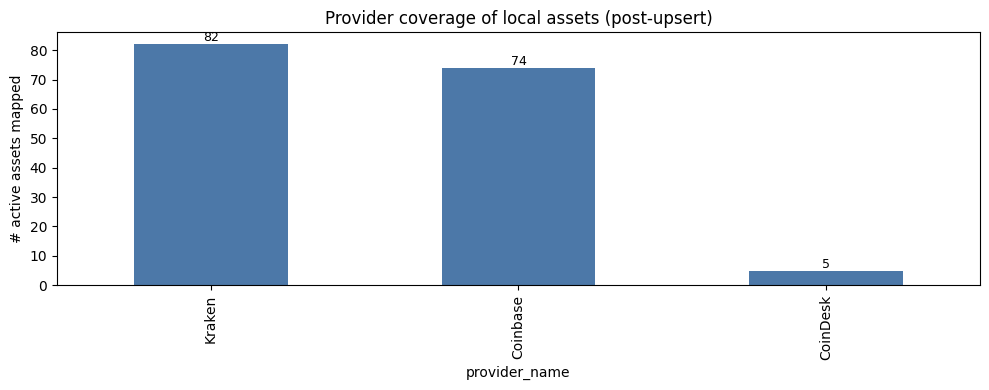

82 assets mapped to Kraken or Coinbase (82 Kraken, 74 Coinbase, 74 both)


,symbol,name,description,Kraken,Coinbase,CoinDesk
id,,,,,,
83,A,A,Vaulta,A,NaN,NaN
8,AAVE,AAVE,Aave Coin,AAVE,AAVE,NaN
12,ADA,ADA,Cardano,ADA,ADA,NaN
63,AERO,AERO,Aerodrome Finance,AERO,AERO,NaN
43,ALGO,ALGO,Algorand,ALGO,ALGO,NaN
...,...,...,...,...,...,...
47,WLD,WLD,Worldcoin,WLD,WLD,NaN
9,XLM,XLM,Stellar Lumens,XXLM,XLM,NaN
30,XMR,XMR,Monero,XXMR,NaN,NaN


In [59]:
import matplotlib.pyplot as plt

post_assets = pd.read_sql(
    select(
        models.Asset.id,
        models.Asset.symbol,
        models.Asset.name,
        models.Asset.description,
    ),
    engine,
)

post_pa = pd.read_sql(
    select(
        models.ProviderAsset.provider_id,
        models.ProviderAsset.asset_id,
        models.ProviderAsset.asset_code,
        models.ProviderAsset.date,
    ).where(models.ProviderAsset.is_active == True),
    engine,
)

latest_pa = (
    post_pa.sort_values("date")
    .drop_duplicates(["asset_id", "provider_id"], keep="last")
    .merge(
        provider_df.rename(columns={"id": "provider_id", "name": "provider_name"}),
        on="provider_id",
    )
)

wide = latest_pa.pivot_table(
    index="asset_id",
    columns="provider_name",
    values="asset_code",
    aggfunc="first",
)

coverage = wide.notna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
coverage.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_ylabel("# active assets mapped")
ax.set_title("Provider coverage of local assets (post-upsert)")
for i, v in enumerate(coverage.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

joined = post_assets.set_index("id").join(wide, how="left")
cols_first = ["symbol", "name", "description"]
provider_cols = [c for c in ["Kraken", "Coinbase"] if c in joined.columns]
extra_providers = [
    c for c in joined.columns if c not in cols_first + provider_cols
]
joined = joined[cols_first + provider_cols + extra_providers]

mask = pd.Series(False, index=joined.index)
for c in provider_cols:
    mask |= joined[c].notna()
focus = joined[mask].sort_values("symbol")

focus.to_csv("provider_asset_state.csv")
print(
    f"{len(focus)} assets mapped to Kraken or Coinbase "
    f"({focus['Kraken'].notna().sum() if 'Kraken' in focus.columns else 0} Kraken, "
    f"{focus['Coinbase'].notna().sum() if 'Coinbase' in focus.columns else 0} Coinbase, "
    f"{(focus.get('Kraken').notna() & focus.get('Coinbase').notna()).sum() if {'Kraken','Coinbase'}.issubset(focus.columns) else 0} both)"
)
focus

In [60]:
focus.to_csv("provider_asset_state.csv")

## Post-upsert sanity test: fresh Coinbase vs fresh Kraken close

Round-trip test that the upsert actually wired things up: re-fetch live Coinbase prices, then look up the local `asset_id` for each Coinbase code by querying the `provider_asset` table we just wrote (no in-memory `matches` dict). Pull the latest Kraken close for those `asset_id`s and compare. Anything within ~5% confirms the mapping is correct; large gaps mean a bad match (collided ticker, wrong asset).

In [61]:
# 1) fresh Coinbase prices via API
fresh_resp = requests.get(PRODUCTS_URL, timeout=30)
fresh_resp.raise_for_status()
fresh_products = pd.DataFrame(fresh_resp.json().get("products", []))
fresh_live = fresh_products.loc[
    (fresh_products["status"] == "online")
    & ~_bool(fresh_products.get("is_disabled", False))
    & ~_bool(fresh_products.get("trading_disabled", False))
    & ~_bool(fresh_products.get("view_only", False))
    & ~_bool(fresh_products.get("auction_mode", False))
].copy()

fresh_usd = fresh_live[fresh_live["quote_currency_id"] == "USD"][
    ["base_currency_id", "price", "product_id"]
].copy()
fresh_usd["price"] = pd.to_numeric(fresh_usd["price"], errors="coerce")
fresh_usd = fresh_usd.rename(
    columns={
        "base_currency_id": "asset_code",
        "price": "coinbase_price",
        "product_id": "coinbase_product_id",
    }
)

# 2) translate Coinbase codes -> local asset_id via the freshly-written provider_asset rows
cb_pa = pd.read_sql(
    select(
        models.ProviderAsset.asset_id,
        models.ProviderAsset.asset_code,
        models.ProviderAsset.date,
    )
    .where(models.ProviderAsset.provider_id == coinbase_provider_id)
    .where(models.ProviderAsset.is_active == True),
    engine,
)
cb_pa = (
    cb_pa.sort_values("date")
    .drop_duplicates(["asset_id", "asset_code"], keep="last")
    [["asset_id", "asset_code"]]
)
cb_priced = cb_pa.merge(fresh_usd, on="asset_code", how="inner")

# 3) fresh Kraken USD closes for those asset_ids (same DISTINCT ON pattern as price_check)
asset_ids = cb_priced["asset_id"].astype(int).tolist()
fresh_cutoff = dt.datetime.now(dt.timezone.utc) - dt.timedelta(days=KRAKEN_LOOKBACK_DAYS)
fresh_kraken = pd.read_sql(
    select(
        models.ProviderAssetMarket.to_asset_id,
        models.ProviderAssetMarket.timestamp,
        models.ProviderAssetMarket.close,
    )
    .where(models.ProviderAssetMarket.timestamp >= fresh_cutoff)
    .where(models.ProviderAssetMarket.provider_id == kraken_provider_id)
    .where(models.ProviderAssetMarket.from_asset_id == usd_asset_id)
    .where(models.ProviderAssetMarket.to_asset_id.in_(asset_ids))
    .order_by(
        models.ProviderAssetMarket.to_asset_id,
        models.ProviderAssetMarket.timestamp.desc(),
    )
    .distinct(models.ProviderAssetMarket.to_asset_id),
    engine,
).rename(
    columns={
        "to_asset_id": "asset_id",
        "close": "kraken_close",
        "timestamp": "kraken_timestamp",
    }
)

# 4) join + compare
fresh_check = (
    cb_priced.merge(fresh_kraken, on="asset_id", how="left")
    .merge(
        post_assets[["id", "name"]].rename(
            columns={"id": "asset_id", "name": "asset_name"}
        ),
        on="asset_id",
        how="left",
    )
)
fresh_check["pct_diff"] = (
    (fresh_check["coinbase_price"] - fresh_check["kraken_close"])
    / fresh_check["kraken_close"]
    * 100
)
fresh_check["abs_pct_diff"] = fresh_check["pct_diff"].abs()
fresh_check = fresh_check.sort_values(
    "abs_pct_diff", ascending=False, na_position="first"
)

n_no_kraken = fresh_check["kraken_close"].isna().sum()
n_big = (fresh_check["pct_diff"].abs() >= 5).sum()
n_ok = len(fresh_check) - n_no_kraken - n_big
print(
    f"Tested {len(fresh_check)} Coinbase USD pairs against Kraken latest close:\n"
    f"  PASS within 5%: {n_ok}\n"
    f"  No Kraken close in last {KRAKEN_LOOKBACK_DAYS}d: {n_no_kraken}\n"
    f"  Differ by 5%+: {n_big}"
)

fresh_check.to_csv("post_upsert_price_check.csv", index=False)
fresh_check[[
    "asset_code",
    "asset_name",
    "asset_id",
    "coinbase_price",
    "kraken_close",
    "pct_diff",
]]

Tested 72 Coinbase USD pairs against Kraken latest close:
  PASS within 5%: 72
  No Kraken close in last 7d: 0
  Differ by 5%+: 0


,asset_code,asset_name,asset_id,coinbase_price,kraken_close,pct_diff
51,XTZ,XTZ,78,0.368800,0.371100,-0.619779
52,WLD,WLD,47,0.238600,0.240000,-0.583333
61,JASMY,JASMY,84,0.005640,0.005670,-0.529101
13,CAKE,CAKE,75,1.461000,1.454000,0.481431
29,S,S,71,0.043990,0.044200,-0.475113
...,...,...,...,...,...,...
16,PEPE,PEPE,32,0.000004,0.000004,0.025132
45,SOL,SOL,7,84.130000,84.120000,0.011888
22,TAO,TAO,35,268.440000,268.454300,-0.005327
50,USDT,USDT,18,0.999830,0.999800,0.003001
